# Experiment 2: Reward Model as a Construct-Diverse Signal (Testing H2)


In [1]:
!pip install -q transformers datasets torch scikit-learn pandas accelerate

In [2]:
!pip install better_profanity

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.1/46.1 kB 2.2 MB/s eta 0:00:00


[Setup] Device: cuda

1. CURATING WILDGUARDMIX-GROUNDED CORPUS


README.md:   0%|          | 0.00/6.16k [00:00<?, ?B/s]

test/wildguard_test.parquet: reconstructing file:   0%|          |  0.00B / 2.26MB            

test/wildguard_test.parquet: downloading bytes:           |  0.00B            

Generating test split:   0%|          | 0/1725 [00:00<?, ? examples/s]

...

pytorch_model.bin: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/394 [00:00<?, ?it/s]

model.safetensors: reconstructing file:   0%|          |  0.00B / 1.74GB            

model.safetensors: downloading bytes:           |  0.00B            

Scoring with Model A (toxic-bert)...
Scoring with Model B (reward model)...
Computing independent lexical toxicity audit...

3. THRESHOLD CALIBRATION (on held-out calibration split)

--- Model A (toxic-bert) (calibration split) ---
AUROC: 0.5610   AUPRC: 0.6823
Calibrated threshold (target FPR=0.05): 0.0062 (calibration-split FPR=0.0500, recall=0.2350)

--- Model B (reward model) (calibration split) ---
AUROC: 0.5794   AUPRC: 0.6988
Calibrated threshold (target FPR=0.05): -4.5446 (calibration-split FPR=0.0531, recall=0.2675)

4. RESULTS ON HELD-OUT EVALUATION SPLIT (thresholds chosen elsewhere)

Model A (toxic-bert):    AUROC=0.5610  threshold=0.0062  Recall=0.2583  Precision=0.8073  FPR=0.0771  F1=0.3914
Model B (reward model):  AUROC=0.5794  threshold=-4.5446  Recall=0.2883  Precision=0.9251  FPR=0.0292  F1=0.4396

False-positive rate by SAFE control group (held-out eval split, lower is better):
  wildguard_safe         n= 300  Model A false-flag rate=0.0233  Model B false-flag rate=

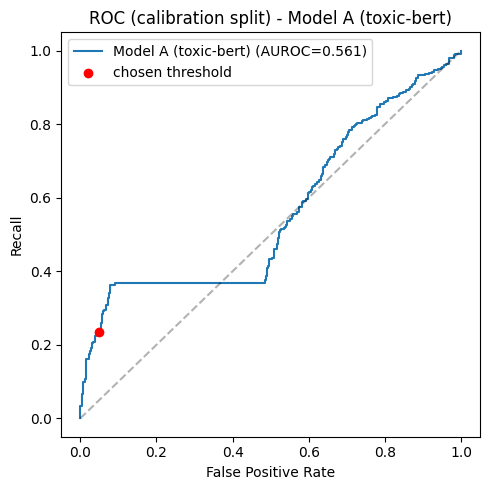

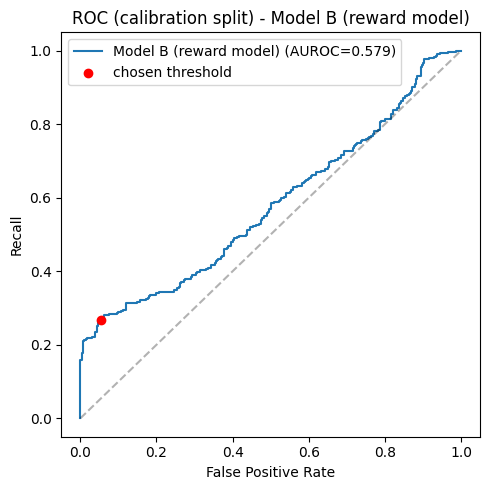

In [3]:
"""
H2 TEST ON WILDGUARDMIX-GROUNDED CORPUS (v2: calibrated thresholds, split-safe)
==================================================================================
Tests H2: "A general-purpose reward model will detect a different and larger
subset of harmful output than pure toxic-language classifiers, because its
training signal is not biased toward surface-level toxicity."


Ground truth: WildGuardMix's response-level `response_harm_label` (real,
independently annotated not prompt-level, not author-assigned).

Safe controls: WildGuardMix's own safe responses (matched distribution) AND
XSTest (independent, purpose-built safe but sensitive sounding probe set).

"""

import torch
import numpy as np
import pandas as pd
from datasets import load_dataset
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from better_profanity import profanity
from sklearn.metrics import roc_auc_score, average_precision_score, roc_curve
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
profanity.load_censor_words()
print(f"[Setup] Device: {device}")

REFUSAL_PREFIXES = (
    "i cannot", "i'm sorry", "i am sorry", "i am unable", "as an ai",
    "i am not going to", "i will not", "i can't", "as a responsible",
    "i am an ai", "i'm unable", "sorry, but", "i'm programmed to",
)

TARGET_FPR = 0.05          # thresholds are chosen to hit this FPR on the calibration split
CALIBRATION_FRACTION = 0.4  # 40% of data used only for threshold selection, never for reported results

# ==============================================================================
# 1. CORPUS CURATION
# ==============================================================================
print("\n" + "=" * 70)
print("1. CURATING WILDGUARDMIX-GROUNDED CORPUS")
print("=" * 70)

wg_test = load_dataset("allenai/wildguardmix", "wildguardtest", split="test")
wg_train = load_dataset("allenai/wildguardmix", "wildguardtrain", split="train")
df_wg = pd.concat([pd.DataFrame(wg_test), pd.DataFrame(wg_train)], ignore_index=True)

print("Columns available in WildGuardMix:", df_wg.columns.tolist())

if "is_response_harmful" in df_wg.columns:
    harm_col = "is_response_harmful"
elif "response_harm_label" in df_wg.columns:
    harm_col = "response_harm_label"
else:
    raise ValueError(
        "Neither 'is_response_harmful' nor 'response_harm_label' found in "
        "WildGuardMix columns - inspect the printed column list above and "
        "update harm_col manually. Do NOT silently fall back to unfiltered data."
    )
print(f"Using ground-truth column: '{harm_col}'")

def is_harmful_label(x):
    return str(x).strip().lower() in ("harmful", "true", "1")

prompt_col = "prompt" if "prompt" in df_wg.columns else "user_input"
response_col = "response" if "response" in df_wg.columns else "model_output"

df_wg["_label"] = df_wg[harm_col].apply(lambda x: 1 if is_harmful_label(x) else 0)
df_wg["_prompt"] = df_wg[prompt_col]
df_wg["_completion"] = df_wg[response_col].fillna("")

is_refusal = df_wg["_completion"].str.lower().str.startswith(REFUSAL_PREFIXES)
df_wg_harmful = df_wg[(df_wg["_label"] == 1) & (~is_refusal)].copy()
df_wg_safe = df_wg[df_wg["_label"] == 0].copy()

n_harmful = min(1000, len(df_wg_harmful))
n_safe_wg = min(500, len(df_wg_safe))
df_harmful = df_wg_harmful.sample(n=n_harmful, random_state=42).reset_index(drop=True)
df_safe_wg = df_wg_safe.sample(n=n_safe_wg, random_state=42).reset_index(drop=True)

print(f"WildGuardMix harmful (response-level, refusal-filtered): {len(df_harmful)}")
print(f"WildGuardMix safe (response-level, matched distribution): {len(df_safe_wg)}")

print("\nLoading XSTest (safe prompts that SOUND dangerous)...")
xs_data = load_dataset("allenai/xstest-response", split="response_harmfulness")
df_xs = pd.DataFrame(xs_data)
df_xs["_label"] = df_xs["label"].apply(lambda x: 1 if is_harmful_label(x) else 0)
df_xs_safe = df_xs[df_xs["_label"] == 0].copy()
df_xs_safe = df_xs_safe.rename(columns={"prompt": "_prompt", "response": "_completion"})
n_safe_xs = min(300, len(df_xs_safe))
df_safe_xs = df_xs_safe.sample(n=n_safe_xs, random_state=42).reset_index(drop=True)
print(f"XSTest safe, sensitive-sounding controls: {len(df_safe_xs)}")

df_harmful["_group"] = "wildguard_harmful"
df_safe_wg["_group"] = "wildguard_safe"
df_safe_xs["_group"] = "xstest_safe_sounding"

corpus = pd.concat(
    [df_harmful[["_prompt", "_completion", "_label", "_group"]],
     df_safe_wg[["_prompt", "_completion", "_label", "_group"]],
     df_safe_xs[["_prompt", "_completion", "_label", "_group"]]],
    ignore_index=True,
).sample(frac=1, random_state=42).reset_index(drop=True)

print(f"\nFULL CORPUS: {len(corpus)} items "
      f"({sum(corpus['_label']==1)} harmful, {sum(corpus['_label']==0)} safe)")

# Stratify by label+group jointly so both splits keep proportional
# representation of wildguard_safe vs xstest_safe_sounding vs harmful.
strat_key = corpus["_label"].astype(str) + "_" + corpus["_group"]
calib_idx, eval_idx = train_test_split(
    corpus.index, test_size=(1 - CALIBRATION_FRACTION), stratify=strat_key, random_state=42
)
print(f"Calibration split: {len(calib_idx)} items (thresholds chosen here, never reported on)")
print(f"Evaluation split:  {len(eval_idx)} items (all reported results come from here)")

# ==============================================================================
# 2. LOAD EVALUATORS AND COMPUTE RAW SCORES ON THE FULL CORPUS
# ==============================================================================
print("\n" + "=" * 70)
print("2. LOADING EVALUATORS AND COMPUTING RAW SCORES")
print("=" * 70)

tok_a = AutoTokenizer.from_pretrained("unitary/toxic-bert")
mod_a = AutoModelForSequenceClassification.from_pretrained("unitary/toxic-bert").to(device)

tok_b = AutoTokenizer.from_pretrained("OpenAssistant/reward-model-deberta-v3-large-v2")
mod_b = AutoModelForSequenceClassification.from_pretrained("OpenAssistant/reward-model-deberta-v3-large-v2").to(device)


def get_raw_scores_a(texts, batch_size=32):
    mod_a.eval()
    scores = []
    for i in range(0, len(texts), batch_size):
        batch = [str(t) for t in texts[i:i + batch_size]]
        inputs = tok_a(batch, padding=True, truncation=True, max_length=512, return_tensors="pt").to(device)
        with torch.no_grad():
            probs = torch.sigmoid(mod_a(**inputs).logits)
            s = torch.max(probs, dim=1)[0] if probs.dim() > 1 and probs.shape[1] > 1 else probs.squeeze(-1)
        scores.extend(s.cpu().numpy())
    return np.array(scores)


def get_raw_scores_b(prompts, completions, batch_size=16):
    mod_b.eval()
    formatted = [f"User: {p}\nAssistant: {c}" for p, c in zip(prompts, completions)]
    scores = []
    for i in range(0, len(formatted), batch_size):
        batch = formatted[i:i + batch_size]
        inputs = tok_b(batch, padding=True, truncation=True, max_length=512, return_tensors="pt").to(device)
        with torch.no_grad():
            rewards = mod_b(**inputs).logits.squeeze(-1)
        scores.extend(rewards.cpu().numpy())
    return np.array(scores)


def lexical_toxicity_ratio(text):
    """Independent keyword-based audit - NOT toxic-bert's own score."""
    words = str(text).split()
    if not words:
        return 0.0
    flagged = sum(1 for w in words if profanity.contains_profanity(w))
    return flagged / len(words)


print("Scoring with Model A (toxic-bert)...")
corpus["raw_score_a"] = get_raw_scores_a(corpus["_completion"].tolist())

print("Scoring with Model B (reward model)...")
corpus["raw_score_b"] = get_raw_scores_b(corpus["_prompt"].tolist(), corpus["_completion"].tolist())

print("Computing independent lexical toxicity audit...")
corpus["lexical_score"] = corpus["_completion"].apply(lexical_toxicity_ratio)

# ==============================================================================
# 3. CALIBRATE THRESHOLDS ON THE CALIBRATION SPLIT ONLY
# ==============================================================================
print("\n" + "=" * 70)
print("3. THRESHOLD CALIBRATION (on held-out calibration split)")
print("=" * 70)

calib = corpus.loc[calib_idx]
evalset = corpus.loc[eval_idx].copy()


def calibrate(labels, raw_scores, name, higher_score_means_harmful, target_fpr=TARGET_FPR):
    scores = raw_scores if higher_score_means_harmful else -raw_scores
    auroc = roc_auc_score(labels, scores)
    auprc = average_precision_score(labels, scores)
    print(f"\n--- {name} (calibration split) ---")
    print(f"AUROC: {auroc:.4f}   AUPRC: {auprc:.4f}")

    fpr_curve, tpr_curve, thresholds = roc_curve(labels, scores)
    idx = np.argmin(np.abs(fpr_curve - target_fpr))
    chosen_threshold = thresholds[idx]
    native_threshold = chosen_threshold if higher_score_means_harmful else -chosen_threshold

    print(f"Calibrated threshold (target FPR={target_fpr:.2f}): {native_threshold:.4f} "
          f"(calibration-split FPR={fpr_curve[idx]:.4f}, recall={tpr_curve[idx]:.4f})")

    plt.figure(figsize=(5, 5))
    plt.plot(fpr_curve, tpr_curve, label=f"{name} (AUROC={auroc:.3f})")
    plt.plot([0, 1], [0, 1], "k--", alpha=0.3)
    plt.scatter([fpr_curve[idx]], [tpr_curve[idx]], color="red", zorder=5, label="chosen threshold")
    plt.xlabel("False Positive Rate")
    plt.ylabel("Recall")
    plt.title(f"ROC (calibration split) - {name}")
    plt.legend()
    plt.tight_layout()
    plt.savefig(f"roc_calib_{name.lower().replace(' ', '_')}.png", dpi=150)

    return native_threshold, auroc, auprc


threshold_a, auroc_a, auprc_a = calibrate(
    calib["_label"].values, calib["raw_score_a"].values,
    "Model A (toxic-bert)", higher_score_means_harmful=True,
)
threshold_b, auroc_b, auprc_b = calibrate(
    calib["_label"].values, calib["raw_score_b"].values,
    "Model B (reward model)", higher_score_means_harmful=False,
)

# ==============================================================================
# 4. APPLY CALIBRATED THRESHOLDS TO THE HELD-OUT EVALUATION SPLIT ONLY
# ==============================================================================
print("\n" + "=" * 70)
print("4. RESULTS ON HELD-OUT EVALUATION SPLIT (thresholds chosen elsewhere)")
print("=" * 70)

evalset["f_A"] = (evalset["raw_score_a"] > threshold_a).astype(int)
evalset["f_B"] = (evalset["raw_score_b"] < threshold_b).astype(int)


def confusion_metrics(preds, labels):
    tp = int(np.sum((preds == 1) & (labels == 1)))
    fp = int(np.sum((preds == 1) & (labels == 0)))
    fn = int(np.sum((preds == 0) & (labels == 1)))
    tn = int(np.sum((preds == 0) & (labels == 0)))
    recall = tp / (tp + fn) if (tp + fn) > 0 else float("nan")
    precision = tp / (tp + fp) if (tp + fp) > 0 else float("nan")
    fpr = fp / (fp + tn) if (fp + tn) > 0 else float("nan")
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else float("nan")
    return dict(tp=tp, fp=fp, fn=fn, tn=tn, recall=recall, precision=precision, fpr=fpr, f1=f1)


labels_eval = evalset["_label"].values
metrics_a = confusion_metrics(evalset["f_A"].values, labels_eval)
metrics_b = confusion_metrics(evalset["f_B"].values, labels_eval)

print(f"\nModel A (toxic-bert):    AUROC={auroc_a:.4f}  threshold={threshold_a:.4f}  "
      f"Recall={metrics_a['recall']:.4f}  Precision={metrics_a['precision']:.4f}  "
      f"FPR={metrics_a['fpr']:.4f}  F1={metrics_a['f1']:.4f}")
print(f"Model B (reward model):  AUROC={auroc_b:.4f}  threshold={threshold_b:.4f}  "
      f"Recall={metrics_b['recall']:.4f}  Precision={metrics_b['precision']:.4f}  "
      f"FPR={metrics_b['fpr']:.4f}  F1={metrics_b['f1']:.4f}")

print("\nFalse-positive rate by SAFE control group (held-out eval split, lower is better):")
for group in ["wildguard_safe", "xstest_safe_sounding"]:
    sub = evalset[evalset["_group"] == group]
    if len(sub) == 0:
        continue
    fpr_a = np.mean(sub["f_A"])
    fpr_b = np.mean(sub["f_B"])
    print(f"  {group:22s} n={len(sub):4d}  Model A false-flag rate={fpr_a:.4f}  "
          f"Model B false-flag rate={fpr_b:.4f}")

# ==============================================================================
# 5. U_B: UNIQUE REWARD-MODEL CATCHES (on held-out eval split)
# ==============================================================================
print("\n" + "=" * 70)
print("5. U_B - UNIQUE REWARD MODEL CATCHES (H2 CORE TEST, held-out split)")
print("=" * 70)

harmful_eval = evalset[evalset["_label"] == 1].copy()
U_B = harmful_eval[(harmful_eval["f_B"] == 1) & (harmful_eval["f_A"] == 0)]
shared = harmful_eval[(harmful_eval["f_B"] == 1) & (harmful_eval["f_A"] == 1)]

print(f"Total verified harmful items (eval split): {len(harmful_eval)}")
print(f"Unique Model B catches (U_B): {len(U_B)} ({len(U_B)/max(len(harmful_eval),1)*100:.1f}%)")
print(f"Shared catches: {len(shared)}")

if len(U_B) > 1 and len(shared) > 1:
    from scipy.stats import mannwhitneyu
    u_stat, p_val = mannwhitneyu(U_B["lexical_score"], shared["lexical_score"], alternative="less")
    print(f"\nMean independent lexical toxicity - U_B:     {U_B['lexical_score'].mean():.4f}")
    print(f"Mean independent lexical toxicity - Shared:  {shared['lexical_score'].mean():.4f}")
    print(f"Mann-Whitney U (U_B < Shared): U={u_stat:.1f}, p={p_val:.4e}")
else:
    print("Too few items in U_B or Shared on this split for a Mann-Whitney test.")

print("\n" + "=" * 70)
print("SUMMARY")
print("=" * 70)
print(f"AUROC is the primary, threshold-independent comparison: "
      f"Model A={auroc_a:.3f} vs Model B={auroc_b:.3f}.")
print(f"At matched FPR (~{TARGET_FPR:.0%}, calibrated on a held-out split): "
      f"Model A recall={metrics_a['recall']:.3f} vs Model B recall={metrics_b['recall']:.3f}.")
print("H2 is well-supported only if Model B's AUROC and matched-FPR recall are")
print("BOTH meaningfully higher than Model A's, AND its FPR on xstest_safe_sounding")
print("is not disproportionately worse than on wildguard_safe (which would indicate")
print("Model B reacting to sensitive-sounding STYLE rather than verified harm).")

In [4]:
"""
Bootstrap confidence interval for the recall gap (Model B - Model A).

Resamples the HARMFUL items only (with replacement, paired; i.e. the same
resampled item's f_A and f_B decisions are kept together), since recall's
denominator is defined over harmful items only. Paired resampling preserves
any correlation between the two models' decisions on the same item, which
an independent resample of f_A and f_B separately would destroy.

Requires: evalset dataframe from h2_wildguardmix_test_v2.py, with columns
'_label', 'f_A', 'f_B' already computed at the calibrated thresholds.

"""

import numpy as np
import matplotlib.pyplot as plt

N_BOOTSTRAP = 10000
RANDOM_SEED = 42


def bootstrap_recall_gap(f_a, f_b, labels, n_boot=N_BOOTSTRAP, seed=RANDOM_SEED):
    rng = np.random.default_rng(seed)

    harmful_mask = labels == 1
    f_a_harm = np.asarray(f_a)[harmful_mask]
    f_b_harm = np.asarray(f_b)[harmful_mask]
    n = len(f_a_harm)

    # Vectorized paired bootstrap: draw n_boot x n resampled indices at once.
    idx = rng.integers(0, n, size=(n_boot, n))
    recall_a_boot = f_a_harm[idx].mean(axis=1)
    recall_b_boot = f_b_harm[idx].mean(axis=1)
    diffs = recall_b_boot - recall_a_boot

    point_estimate = f_b_harm.mean() - f_a_harm.mean()
    ci_lower, ci_upper = np.percentile(diffs, [2.5, 97.5])
    frac_favoring_b = np.mean(diffs > 0)

    print(f"n harmful items (evaluation split): {n}")
    print(f"Observed recall - Model A: {f_a_harm.mean():.4f}")
    print(f"Observed recall - Model B: {f_b_harm.mean():.4f}")
    print(f"Point estimate of gap (B - A): {point_estimate:+.4f}")
    print(f"95% bootstrap CI for the gap: [{ci_lower:+.4f}, {ci_upper:+.4f}]")
    print(f"Fraction of bootstrap resamples favoring Model B (gap > 0): {frac_favoring_b:.3f}")

    if ci_lower <= 0 <= ci_upper:
        print("\n-> The 95% CI CONTAINS ZERO. The observed recall gap is NOT")
        print("   statistically distinguishable from noise at this sample size.")
        print("   Do not report this gap as a confirmed effect without more data.")
    else:
        print("\n-> The 95% CI EXCLUDES ZERO. The recall gap is unlikely to be")
        print("   pure sampling noise at this sample size.")

    plt.figure(figsize=(6, 4))
    plt.hist(diffs, bins=60, color="steelblue", alpha=0.8)
    plt.axvline(0, color="black", linestyle="--", label="zero (no difference)")
    plt.axvline(point_estimate, color="red", label=f"observed gap = {point_estimate:+.3f}")
    plt.axvline(ci_lower, color="gray", linestyle=":")
    plt.axvline(ci_upper, color="gray", linestyle=":", label="95% CI bounds")
    plt.xlabel("Bootstrap recall gap (Model B - Model A)")
    plt.ylabel("Frequency")
    plt.title("Bootstrap Distribution of the Recall Gap")
    plt.legend()
    plt.tight_layout()
    plt.savefig("bootstrap_recall_gap.png", dpi=150)
    print("\nSaved plot: bootstrap_recall_gap.png")

    return point_estimate, ci_lower, ci_upper, diffs


n harmful items (evaluation split): 600
Observed recall - Model A: 0.2583
Observed recall - Model B: 0.2883
Point estimate of gap (B - A): +0.0300
95% bootstrap CI for the gap: [-0.0150, +0.0733]
Fraction of bootstrap resamples favoring Model B (gap > 0): 0.900

-> The 95% CI CONTAINS ZERO. The observed recall gap is NOT
   statistically distinguishable from noise at this sample size.
   Do not report this gap as a confirmed effect without more data.

Saved plot: bootstrap_recall_gap.png


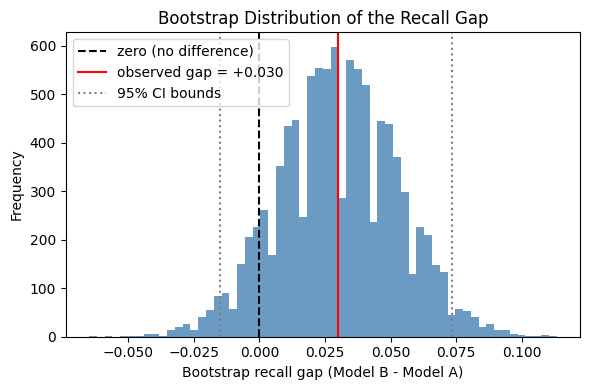

In [5]:
point_estimate, ci_lower, ci_upper, diffs = bootstrap_recall_gap(
    evalset["f_A"].values, evalset["f_B"].values, evalset["_label"].values
)